# Simple Template Attack on the First Weight

This notebook recovers `net_config_weights.lay1_weights[0][0]` (the true value is `1.43`, see `firmware/network_config.h`) using a **profiled template attack**.

This weight is the natural first target: it is the only weight multiplied directly by the attacker-controlled input (`net.layers[0].neurons[0].a = input_value` in `firmware/main.c`), so the leaking product is exactly `weight * input` with a fully known/chosen `input`.

### Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import struct
from decimal import Decimal
from scipy.stats import norm
import chipwhisperer as cw


/home/piskotka/.local/lib/python3.14/site-packages/chipwhisperer/capture/trace/TraceWhisperer.py:31: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources # type: ignore


### Candidate weight values

Same 401-value sweep from `-2.00` to `2.00`.

In [2]:
total_num_of_weight = 401
def get_weights_arr():
    weights_arr = []
    w_val = Decimal('-2.0')
    step = Decimal('0.01')
    for i in range(total_num_of_weight):
        weights_arr.append(float(w_val))
        w_val += step
    return weights_arr

weights_arr = get_weights_arr()
true_weight = 1.43  # net_config_weights.lay1_weights[0][0], firmware/network_config.h


### Leakage model

Hamming weight of the IEEE-754 bit pattern of the hypothetical product `weight * input` — identical leakage model to `CPA_vs_traces.ipynb`, just scored differently below (template log-likelihood instead of Pearson correlation).

In [3]:
def float_to_binary_str(f):
    [packed] = struct.unpack('!I', struct.pack('!f', f))
    return f"{packed:032b}"

def HW_float32(f):
    return float_to_binary_str(f).count('1')


### Load traces

In [4]:
def load_traces(num_of_traces):
    proj = cw.open_project("../data/raw/CPA_NN")
    trace_waves_arr = np.array(proj.waves[:num_of_traces]).astype(float)
    inputs_arr = np.array(proj.textins[:num_of_traces]).astype(float)
    return trace_waves_arr, inputs_arr


### Load & split into profiling / attack sets

Profiling traces are used (with the *known* true weight) purely to build the per-class templates.

In [5]:
traces, inputs = load_traces(num_of_traces=10000)

n_profile = 8000
profile_traces, profile_inputs = traces[:n_profile], inputs[:n_profile]
attack_traces,  attack_inputs  = traces[n_profile:], inputs[n_profile:]

print(f"{len(profile_traces)} profiling traces, {len(attack_traces)} attack traces")


8000 profiling traces, 2000 attack traces


### Step 1 — Point of interest (POI) selection

Templates need a POI, chosen here via signal-to-noise ratio (SNR) on the *profiling* set, where the true weight is known so exact Hamming-weight labels can be computed. This is the template-attack analogue of the correlation sweep in `CPA_vs_traces.ipynb`; adjust `start`/`end` to match the window you already identified there (`start = 490`, `end = 1011`).

In [6]:
start = 490
end = 1011

def hw_labels(inputs_arr, weight):
    return np.array([HW_float32(weight * x) for x in inputs_arr])

profile_labels = hw_labels(profile_inputs, true_weight)

def find_poi(window, labels):
    classes = np.unique(labels)
    means = np.array([window[labels == c].mean(axis=0) for c in classes])
    varis = np.array([window[labels == c].var(axis=0)  for c in classes])
    snr = means.var(axis=0) / varis.mean(axis=0)
    return snr

snr = find_poi(profile_traces[:, start:end], profile_labels)
poi = start + int(np.argmax(snr))
print(f"Selected POI: sample {poi} (SNR = {snr.max():.3f})")


Selected POI: sample 569 (SNR = 19.043)


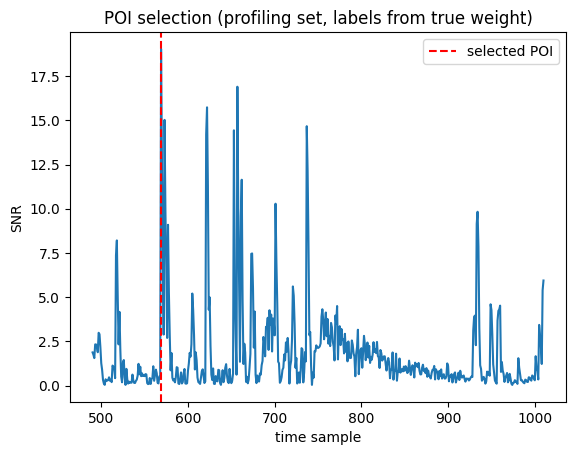

In [7]:
plt.plot(range(start, end), snr)
plt.axvline(poi, color='r', linestyle='--', label='selected POI')
plt.xlabel('time sample')
plt.ylabel('SNR')
plt.legend()
plt.title('POI selection (profiling set, labels from true weight)')
plt.show()


### Step 2 — Build one Gaussian template per Hamming-weight class

For each HW class observed while profiling, fit a 1-D Gaussian (mean, std) to the profiling traces' amplitude at `poi`.

In [8]:
templates = {
    c: (profile_traces[profile_labels == c, poi].mean(),
        profile_traces[profile_labels == c, poi].std())
    for c in np.unique(profile_labels)
}

print(f"Built {len(templates)} class templates")
for c in sorted(templates)[:5]:
    mu, sigma = templates[c]
    print(f"  HW={c:2d}: mean={mu:.4f}, std={sigma:.4f}")


Built 25 class templates
  HW= 3: mean=-0.0830, std=0.0000
  HW= 4: mean=-0.0874, std=0.0005
  HW= 5: mean=-0.0952, std=0.0054
  HW= 6: mean=-0.0925, std=0.0081
  HW= 7: mean=-0.0904, std=0.0028


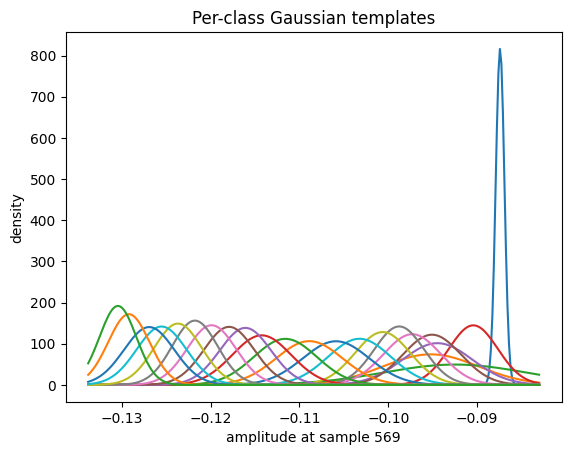

In [9]:
xs = np.linspace(profile_traces[:, poi].min(), profile_traces[:, poi].max(), 300)
for c, (mu, sigma) in sorted(templates.items()):
    if sigma > 0:
        plt.plot(xs, norm.pdf(xs, mu, sigma), label=f'HW={c}')
plt.xlabel(f'amplitude at sample {poi}')
plt.ylabel('density')
plt.title('Per-class Gaussian templates')
plt.show()


### Step 3 — Attack: score every candidate weight

For each held-out attack trace with known input `x`, and for every candidate weight in `weights_arr`, look up the Hamming-weight class the candidate implies for that `x`, then add the log-likelihood of the observed amplitude under that class's template. This is the template-attack analogue of `CPA_attack`'s correlation sum — same candidate sweep, likelihood instead of correlation.

In [10]:
scores = np.zeros(len(weights_arr))

for x, t in zip(attack_inputs, attack_traces):
    v = t[poi]
    for i, w in enumerate(weights_arr):
        c = HW_float32(w * x)
        if c not in templates:
            continue  # HW class never seen while profiling
        mu, sigma = templates[c]
        if sigma == 0:
            continue
        scores[i] += norm.logpdf(v, mu, sigma)


### Step 4 — Recover the weight

In [11]:
best_idx = int(np.argmax(scores))
recovered_weight = weights_arr[best_idx]

print(f"Recovered weight: {recovered_weight:.2f}")
print(f"True weight:      {true_weight}")


Recovered weight: 1.43
True weight:      1.43


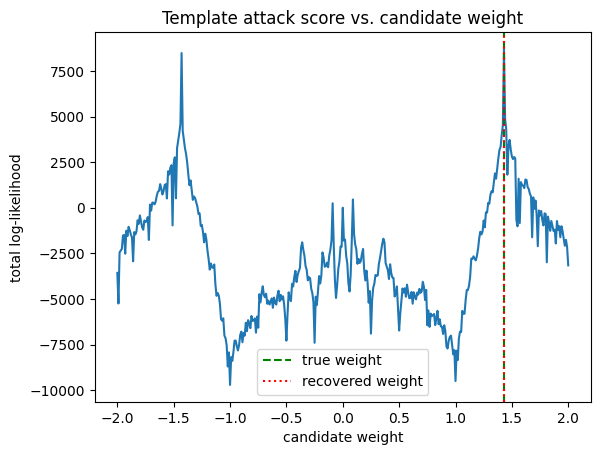

In [12]:
plt.plot(weights_arr, scores)
plt.axvline(true_weight, color='g', linestyle='--', label='true weight')
plt.axvline(recovered_weight, color='r', linestyle=':', label='recovered weight')
plt.xlabel('candidate weight')
plt.ylabel('total log-likelihood')
plt.legend()
plt.title('Template attack score vs. candidate weight')
plt.show()


### Next steps

- Repeat with fewer attack traces to find how many are actually needed for a unique recovery (compare data efficiency against `CPA_vs_traces.ipynb`'s `run_CPA_n_traces`).
- Extend from a single POI to 2–3 POIs with a pooled covariance matrix (`scipy.stats.multivariate_normal`) instead of independent 1-D Gaussians.
- If a genuinely profiled (cross-device) attack is wanted for the thesis, this requires firmware/build changes so the target weight can be set at runtime rather than compiled into `network_config.h`.